# Spam Mail Detector


## Objective

The objective of this project is to build a machine learning model that can classify SMS messages into two categories:

- Spam
- Ham (Not Spam)

The project uses Natural Language Processing (NLP) techniques to preprocess text messages, convert them into numerical features using TF-IDF Vectorization, and classify them using the Multinomial Naive Bayes algorithm.

The performance of the model is evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [21]:
pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [23]:
import pandas as pd

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5572, 2)


In [25]:
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [27]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [28]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

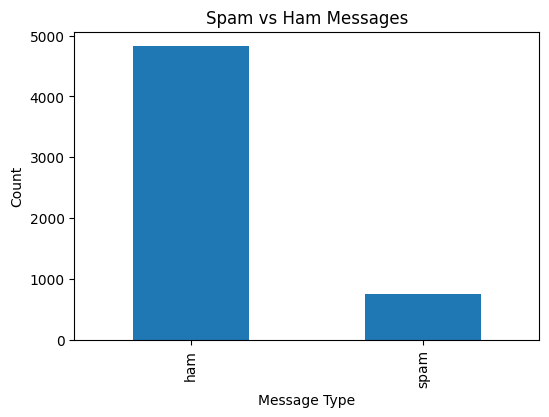

In [29]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

## Label Encoding

In [30]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Prepare Features and Target

In [31]:
X = df["message"]
y = df["label"]

print("Number of Messages:", len(X))
print("Number of Labels:", len(y))

Number of Messages: 5572
Number of Labels: 5572


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Messages:", len(X_train))
print("Testing Messages:", len(X_test))

Training Messages: 4457
Testing Messages: 1115


## TF-IDF Vectorization

In [33]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

print("Training Matrix Shape:", X_train.shape)
print("Testing Matrix Shape:", X_test.shape)

Training Matrix Shape: (4457, 7403)
Testing Matrix Shape: (1115, 7403)


## Train the Naive Bayes Model

In [34]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [35]:
y_pred = model.predict(X_test)

print("First 20 Predictions:")
print(y_pred[:20])

First 20 Predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Model Evaluation

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9704035874439462
Accuracy Percentage: 97.04035874439462 %


### Classification Report

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### Confusion Matrix

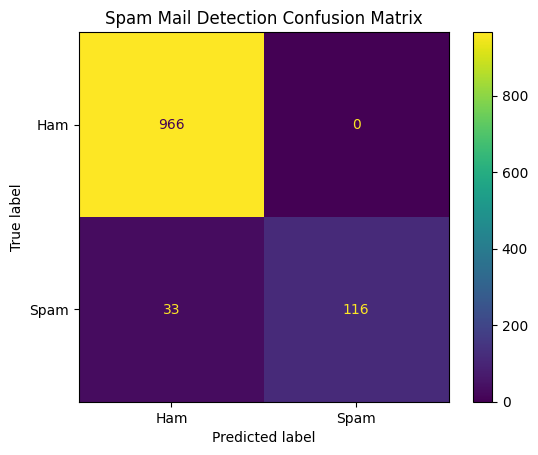

In [38]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

display.plot()

plt.title("Spam Mail Detection Confusion Matrix")

plt.show()

## Test with a Custom Message

In [39]:
sample_message = [
    "Congratulations! You have won a FREE iPhone. Click here to claim your prize."
]

sample_vector = vectorizer.transform(sample_message)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")

Prediction: Spam


In [40]:
sample_message = [
    "Hi, are we meeting at the library tomorrow?"
]

sample_vector = vectorizer.transform(sample_message)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")

Prediction: Ham


## Conclusion

In this project, a Spam Mail Detector was developed using Natural Language Processing (NLP) and Machine Learning techniques.

The SMS Spam Collection dataset was loaded and explored to understand the distribution of spam and ham messages. The text data was converted into numerical features using TF-IDF Vectorization.

A Multinomial Naive Bayes classifier was trained on the processed data to distinguish between spam and legitimate messages.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The trained model successfully classified new SMS messages as either Spam or Ham.

This project demonstrates the complete NLP workflow, including text preprocessing, feature extraction, model training, prediction, and evaluation.